In [1]:
using LaMEM, GeophysicalModelGenerator, Plots

ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
┌ Warning: Module LaMEM with build ID ffffffff-ffff-ffff-0000-029f125327e1 is missing from the cache.
│ This may mean LaMEM [2e889f3d-35ce-4a77-8ea2-858aecb630f7] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:1948


Adding Plots.jl plotting extensions for LaMEM


In [ ]:
## define varibles
# slab breakoff depth
breakoff_depth = -100

# Arc crust: 
# Moho temperature
TarcMoho = 700                   #  hot arc Moho temperature at 700 C for  hot case, linear gradient of 20C/km


# define crustal thickness
Indian_crust_thickess = 25
Indian_crust_thickess_sediment = 2
Indian_crust_thickess_upper = 12

Indian_margin_crust_thickess = 25
Indian_margin_crust_thickess_sediment = 2
Indian_margin_crust_thickess_upper = 12

Asian_crust_thickess = 35
Asian_crust_thickess_upper = 18

arc_crust_thickness = 40 # km
arc_crust_thickness_upper = 20 #km

reduction_ratio = 0.95 # for plastic softening

0.95

In [3]:
# set up model size, horizontal 4000 km and depth to 1200 km 
# also include 10 km air

########################
#  change air thickness from 20 to 10 km
########################
#  May increase local resolution to 1 km (not done yet)
########################
#  need to add passive tracers (not done yet)
########################

model = Model(   Grid(coord_x=[-2000, -200, 200, 2000], bias_x=[0.125,1.0,8.0], nel_x=[200,400,200],
                      coord_y=[-1,1],                   bias_y=[1.0],         nel_y=[1],
                      coord_z=[-1200, -220, 20],        bias_z=[0.2,1.0],     nel_z=[80,240]),

                    PassiveTracers(
                      Passive_Tracer=1, # acticve passive tracer
                      PassiveTracer_Box=[0,600,-1,1,-150,0],  # range of passive tracer coordinate: x_left, x_right, y_negative, y_positive, z_bottom, Z_top
                      PassiveTracer_Resolution  =  [600,1,150]), # resolution in x, y, z direction, the limit of passive tracer is 1e6
    
                    BoundaryConditions( temp_bot        = 1744.0,  # we use 1300C for mantle temp at LAB (at - 90km),  with 0.4 C/km Adiabat gradient, the bottom temp is 1744 C
                                        temp_top        = 20.0,
                                        open_top_bound  = 1),
                    Scaling(GEO_units(  temperature     = 1000,
                                        stress          = 1e9,
                                        length          = 1,
                                        viscosity       = 1e20) )
                     )  

model.Grid

LaMEM grid with 1D refinement: 
  nel         : ([200, 400, 200], [1], [80, 240])
  marker/cell : (3, 3, 3)
  x           ϵ [-2000.0, -200.0, 200.0, 2000.0], bias=[0.125, 1.0, 8.0], nseg=3, Δmin=1.0, Δmax=16.0
  y           ϵ [-1.0 : 1.0]
  z           ϵ [-1200.0, -220.0, 20.0], bias=[0.2, 1.0], nseg=2, Δmin=1.0, Δmax=20.416666666666742
  Phases      : range ϵ [0 - 0]
  Temp        : range ϵ [0.0 - 0.0]


In [4]:
###################
# Non-default setup suggested by Nico
###################

model.ModelSetup = ModelSetup(
                                advect         = "rk2",              # advection scheme
                                interp         = "stag",             # velocity interpolation scheme
                                mark_ctrl      = "subgrid",          # marker control type
                                nmark_lim      = [27, 64],           # min/max number per cell
                                nmark_sub      = 3                   # max number of same phase markers per subcell (subgrid marker control)
                            )

LaMEM Model Setup options: 
  msetup            = files 
  rand_noise        = 1 
  rand_noiseGP      = 1 
  bg_phase          = 0 
  save_mark         = 1 
  mark_load_file    = ./markers/mdb 
  mark_save_file    = ./markers/mdb 
  poly_file         = ./input/poly.dat 
  temp_file         = ./input/temp.dat 
  advect            = rk2 
  interp            = stag 
  stagp_a           = 0.7 
  mark_ctrl         = subgrid 
  nmark_lim         = [27, 64] 
  nmark_avd         = [3, 3, 3] 
  nmark_sub         = 3 
  geom_primitives   = 

In [ ]:
###################
# Model runtime to 20 Myr
# Could be shorter for shallow breakoff
###################

model.Time = Time(  time_end  = 20.0,
                    dt        = 0.0005,  # used to be 0.001 
                    dt_min    = 0.000001,
                    dt_max    = 0.1,
                    nstep_max = 500000,
                    nstep_out = 50,
                    CFL       = 0.2,     # used to be 0.5
                    CFLMAX    = 0.8,
                 )

LaMEM Timestepping parameters: 
  time_end        = 20.0 
  dt              = 0.0005 
  dt_min          = 1.0e-6 
  dt_max          = 0.1 
  dt_out          = 0.2 
  inc_dt          = 0.1 
  CFL             = 0.2 
  CFLMAX          = 0.8 
  nstep_max       = 500000 
  nstep_out       = 50 
  nstep_rdb       = 100 
  nstep_ini       = 1 
  time_tol        = 1.0e-8 


In [6]:
model.SolutionParams = SolutionParams(  shear_heat_eff = 1.0,  
                                        Adiabatic_Heat = 1.0,
                                        act_temp_diff  = 1,
                                        FSSA = 1.0,     
                                        eta_min   = 5e18,
                                        eta_ref   = 1e21,
                                        eta_max   = 1e25,
                                        min_cohes = 1e3,
                                    )

LaMEM Solution parameters : 
  gravity         = [0.0, 0.0, -9.81] 
  FSSA            = 1.0 
  FSSA_allVel     = 1 
  shear_heat_eff  = 1.0 
  Adiabatic_Heat  = 1.0 
  act_temp_diff   = 1 
  act_therm_exp   = 1 
  act_steady_temp = 1 
  steady_temp_t   = 0.0 
  nstep_steady    = 1 
  act_heat_rech   = 1 
  init_lith_pres  = 0 
  init_guess      = 1 
  p_litho_visc    = 1 
  p_litho_plast   = 1 
  p_lim_plast     = 1 
  p_shift         = 0 
  act_p_shift     = 1 
  eta_min         = 5.0e18 
  eta_max         = 1.0e25 
  eta_ref         = 1.0e21 
  T_ref           = 20.0 
  RUGC            = 8.31 
  min_cohes       = 1000.0 
  min_fric        = 5.0 
  tau_ult         = 1.0e9 
  rho_fluid       = 1000.0 
  gw_level_type   = top 
  gw_level        = 1.0e100 
  biot            = 1.0 
  get_permea      = 1.0 
  rescal          = 1.0 
  mfmax           = 0.15 
  lmaxit          = 25 
  lrtol           = 1.0e-6 
  act_dike        = 1 
  useTk           = 1 
  dikeHeat        = 1 
  adiabatic_g

In [7]:
# To start a test run, we did not include surface processes
# surface level is set to 0 km by default

model.FreeSurface = FreeSurface(    surf_use        = 1,                # free surface activation flag
                                    surf_corr_phase = 1,                # air phase ratio correction flag (due to surface position)
                                    surf_level      = 0.0,              # initial level
                                    surf_air_phase  = 0,                # phase ID of sticky air layer
                                    surf_max_angle  = 40.0 ,             # maximum angle with horizon (smoothed if larger))
                                    sediment_model  = 0,
                                    erosion_model   = 0
                                )

LaMEM Free Surface parameters: 
  surf_use        = 1 
  surf_corr_phase = 1 
  surf_level      = 0.0 
  surf_air_phase  = 0 
  surf_max_angle  = 40.0 
  surf_topo_file  =  
  erosion_model   = 0 
  er_num_phases   = 3 
  er_time_delims  = [0.5, 2.5] 
  er_rates        = [0.2, 0.1, 0.2] 
  er_levels       = [1, 2, 1] 
  sediment_model  = 0 
  sed_num_layers  = 3 
  sed_time_delims = [0.5, 2.5] 
  sed_rates       = [0.3, 0.2, 0.3] 
  sed_levels      = [-5.0, -2.0, -2.0] 
  sed_phases      = [1, 2, 3] 
  marginO         = [0.0, 0.0] 
  marginE         = [10.0, 10.0] 
  hUp             = 1.5 
  hDown           = 0.1 
  dTrans          = 1.0 
  Topography      = nothing 


In [ ]:
########################
# output strain rate and dev stress tensors
########################
# need to output trackers information
########################

model.Output = Output(  out_density         = 1,
                        out_j2_strain_rate  = 1,
                        out_strain_rate     = 1,
                        out_surf            = 1, 	
                        out_surf_pvd        = 1,
                        out_surf_topography = 1,
                        out_j2_dev_stress   = 1,
                        out_dev_stress      = 1,
                        out_pressure        = 1,
                        out_temperature     = 1,
                        out_ptr          =  1,     # activate
                        out_ptr_ID       =  1,     # ID of the passive tracers
                        out_ptr_phase    =  1,     # phase of the passive tracers
                        out_ptr_Pressure  =  1,     # interpolated pressure
                        out_ptr_Temperature  =  1,     # temperature 
                          )

LaMEM Output options: 
  out_file_name        = output 
  out_dir              =  
  param_file_name      = output.dat 
  write_VTK_setup      = true 
  out_pvd              = 1 
  out_phase            = 1 
  out_density          = 1 
  out_visc_total       = 1 
  out_visc_creep       = 1 
  out_velocity         = 1 
  out_pressure         = 1 
  out_tot_press        = 0 
  out_eff_press        = 0 
  out_over_press       = 0 
  out_litho_press      = 0 
  out_pore_press       = 0 
  out_temperature      = 1 
  out_dev_stress       = 1 
  out_j2_dev_stress    = 1 
  out_strain_rate      = 1 
  out_j2_strain_rate   = 1 
  out_shmax            = 0 
  out_ehmax            = 0 
  out_yield            = 0 
  out_rel_dif_rate     = 0 
  out_rel_dis_rate     = 0 
  out_rel_prl_rate     = 0 
  out_rel_pl_rate      = 0 
  out_plast_strain     = 0 
  out_plast_dissip     = 0 
  out_tot_displ        = 0 
  out_moment_res       = 0 
  out_cont_res         = 0 
  out_energ_res        = 0 
  out_mel

In [9]:
# define some constant temperatures
# define adiabat mantle temperature gradient : 0.4 C/km

Tair            = 20.0;
Tmantle         = 1300.0;
Adiabat         = 0.4

0.4

In [10]:
# set all model temp to mantle temp, will be overwritten later

model.Grid.Temp     .= Tmantle ;            # set mantle temperature (without adiabat at first)
model.Grid.Phases   .= 1;                   # Set Phases to 0 everywhere (#1 is  asthenosphere in this setup)

In [11]:
# phase above Z> 0 km is assigned for air temperature
# phase above Z> 0 km is assigned for air phase (#0 phase)

model.Grid.Temp[model.Grid.Grid.Z .> 0]    .=  Tair;
model.Grid.Phases[model.Grid.Grid.Z .> 0.0 ] .= 0;

#### **Indian continental plate**

In [ ]:
# Indian continental plate (major part)
# Crustal thickness (35) and LAB depth (135) from Wang et al., 2023. Secular craton evolution due to cyclic deformation of underlying dense mantle lithosphere. Nature Geoscience.

add_box!(model;  xlim    = (-2000.0, -750.0), 
                ylim    = (model.Grid.coord_y...,), 
                zlim    = (-120.0, 0.0),
                Origin  = nothing, StrikeAngle=0, DipAngle=0,
                phase   = LithosphericPhases(Layers=[Indian_crust_thickess_sediment Indian_crust_thickess_upper Indian_crust_thickess-Indian_crust_thickess_sediment-Indian_crust_thickess_upper 120-Indian_crust_thickess], Phases=[14 15 16 3 1] ),
                T       = LinearTemp(               Ttop        = Tair,
                                                    Tbot        = Tmantle
                                                     ))

# Indian continental plate (thinned part)

add_box!(model;  xlim    = (-750.0, -250.0), 
ylim    = (model.Grid.coord_y...,), 
zlim    = (-120, 0.0),
Origin  = nothing, StrikeAngle=0, DipAngle=0,
phase   = LithosphericPhases(Layers=[Indian_margin_crust_thickess_sediment Indian_margin_crust_thickess_upper Indian_margin_crust_thickess-Indian_margin_crust_thickess_sediment-Indian_margin_crust_thickess_upper 120-Indian_margin_crust_thickess], Phases=[14 15 16 3 1] ),
T       = LinearTemp(                Ttop        = Tair,
                                     Tbot        = Tmantle   
                                     ) )                                                  

#### **Asian continental plate**

In [ ]:
# Asian continental plate (thinned part)
# Slightly thinned compared to the rest of the Asian plate (30 crust + 70 mantle lithosphere)

add_box!(model;  xlim    = (250.0, 350.0), 
                ylim    = (model.Grid.coord_y...,), 
                zlim    = (-100, 0.0),
                Origin  = nothing, StrikeAngle=0, DipAngle=0,
                phase   = LithosphericPhases(Layers=[15 15 70], Phases=[12 13 4 1] ),   
                T       = LinearTemp(                Ttop        = Tair,
                                                     Tbot        = Tmantle  
                                                     ) )

# Asian continental plate (the major part)
# Crustal thickness (35) and mantle lithosphere (100) from Wang et al., 2023. Secular craton evolution due to cyclic deformation of underlying dense mantle lithosphere. Nature Geoscience.

add_box!(model;  xlim    = (350.0, 2000.0), 
                ylim    = (model.Grid.coord_y...,), 
                zlim    = (-135, 0.0),
                Origin  = nothing, StrikeAngle=0, DipAngle=0,
                phase   = LithosphericPhases(Layers=[Asian_crust_thickess_upper Asian_crust_thickess-Asian_crust_thickess_upper 135-Asian_crust_thickess], Phases=[12 13 4 1] ),
                T       = LinearTemp(                Ttop        = Tair,
                                                     Tbot        = Tmantle
                                                     ) )


#### **Gangdese arc**

In [14]:
# Arc phase, from trench 200-300 km
# trench is 100 km left of the leftmost margin of Asian plate due to accretionary complex
# so arc is 100-200 km from the leftmost margin (x=250) of Asian plate (so arc location is x=350-450)

###############################################################################
# Crust and mantle lithosphere are added seperately to set different temperatures
###############################################################################

# Arc crust: 


add_box!(model;  xlim    = (350.0, 450.0), 
                ylim    = (model.Grid.coord_y...,),  
                zlim    = (-arc_crust_thickness, 0.0),                          # from 0 to -35 km, 35 km thick
                Origin  = nothing, StrikeAngle=0, DipAngle=0,
                phase   = LithosphericPhases(Layers=[arc_crust_thickness_upper arc_crust_thickness-arc_crust_thickness_upper], Phases=[17 18 8] ),                  # arc phase #15, 16, 17
                T       = LinearTemp(Ttop        = Tair,
                                     Tbot        = TarcMoho
                ))

# Arc mantle lithophere: 

add_box!(model;  xlim    = (350.0, 450.0), 
                ylim    = (model.Grid.coord_y...,), 
                zlim    = (-arc_crust_thickness- 100, -arc_crust_thickness),                         # from - 35 to -135 km, 100 km thick
                Origin  = nothing, StrikeAngle=0, DipAngle=0,
                phase   = ConstantPhase(8),                    # arc mantle lithophere phase #17
                T       = LinearTemp(Ttop        = TarcMoho,
                                     Tbot        = Tmantle
                ))

####  **Tethyan oceanic plate**

In [15]:
# This is oceanic plate to be convergened (500 km wide)
# 90 km thick for the whole lithosphere consistant with halfspace cooling age at ~80 Ma

add_box!(model;  xlim    = (-250.0, 250.0), 
                ylim    = (model.Grid.coord_y..., ), 
                zlim    = (-90.0, 0.0),
                Origin  = nothing, StrikeAngle=0, DipAngle=0,
                phase   = LithosphericPhases(Layers=[7 83], Phases=[10 2 1] ),
                T       = HalfspaceCoolingTemp(    Tsurface    = Tair,
                                                   Tmantle     = Tmantle,
                                                   Age         = 80 ))

#### **Weak zone along oceanic slab interface**

In [16]:
# Weak zone on top of pre-subducted oceanic plate to faciliate initial decoupling

add_box!(model;  xlim    = (260, 550), 
                ylim    = (model.Grid.coord_y...,), 
                zlim    = (-5.0, 0.0),
                Origin  = nothing, StrikeAngle=0, DipAngle=30,
                phase   = ConstantPhase(6),
                T       = nothing ) 

#### **Pre-subducted oceanic plate at the leading edge of Asain plate**

In [17]:
# the starting position is at x= 250 km, given the 30 deg angle and the top is at 130 km depth

add_box!(model;  xlim    = (250, 550), 
                ylim    = (model.Grid.coord_y...,), 
                zlim    = (-90.0, 0.0),
                Origin  = nothing, StrikeAngle=0, DipAngle=30,
                phase   = LithosphericPhases(Layers=[7 83], Phases=[10 2 1], Tlab=Tmantle ),
                T       = HalfspaceCoolingTemp(     Tsurface    = Tair,
                                                    Tmantle     = Tmantle,
                                                    Age         = 80      ) )

#### **Control boxes for triggering slab breakoff**

In [18]:
# control box: oceanic crust part # 12 top 7 km 

add_box!(model;  xlim    = (-250, -240), 
                ylim    = (model.Grid.coord_y...,), 
                zlim    = (-7.0, 0.0),
                Origin  = nothing, StrikeAngle=0, DipAngle=0,
                phase   = ConstantPhase(11),
                T       = nothing ) 

# control box: oceanic lithospheric mantle part # 13

add_box!(model;  xlim    = (-250, -240), 
                ylim    = (model.Grid.coord_y...,), 
                zlim    = (-90.0, -7.0),
                Origin  = nothing, StrikeAngle=0, DipAngle=0,
                phase   = ConstantPhase(5),
                T       = nothing ) 


In [19]:
# add Adiabat temperture profile when Z < -90 km, use the LAB depth of oceanic lithosphere

model.Grid.Temp[model.Grid.Grid.Z .< -90]   .=  model.Grid.Temp[model.Grid.Grid.Z.< -90] .- model.Grid.Grid.Z[model.Grid.Grid.Z.< -90].*Adiabat;  # "-" sign is used since Z is a negative value(corrdinate)

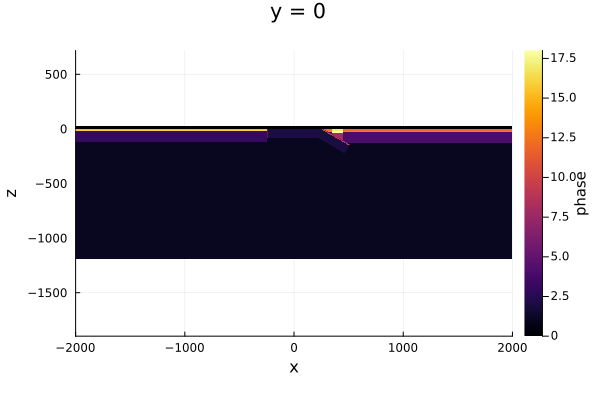

In [20]:
plot_cross_section(model, y=0, field=:phase)


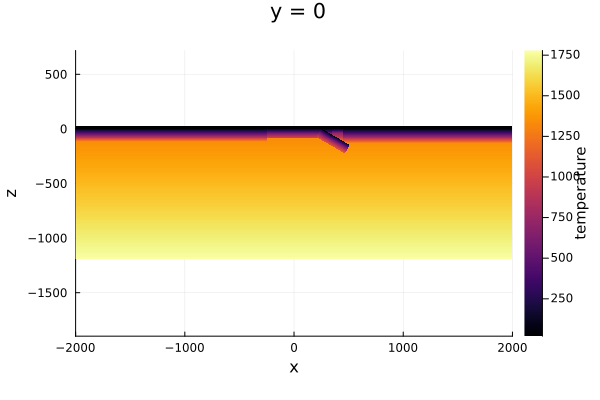

In [21]:
plot_cross_section(model, y=0, field=:temperature)


#### **add softening law**

In [22]:
# Softening
softening =       Softening(    ID   = 0,   			# softening law ID
                                APS1 = 0.1, 			# begin of softening APS
                                APS2 = 0.5, 			# end of softening APS
                                A    = reduction_ratio, 		    # reduction ratio
)

Softening Law 0: 
  APS1   = 0.1 
  APS2   = 0.5 
  A      = 0.95 


In [23]:
air         = Phase(    Name        = "air",                                     
                        ID          = 0,                                                # phase id 
                        rho         = 50.0,                                             # density [kg/m3]                                           # coeff. of thermal expansion [1/K]
                        eta         = 1e19,
                        G           = 5e10,                                             # elastic shear module [Pa]
                        k           = 100,                                              # conductivity
                        Cp          = 1e6,                                              # heat capacity
                        ch          = 10e6,                                             # cohesion [MPa]
                        fr          = 0.0,                                              # friction angle	
                    )

Phase 0 (air): 
  rho       = 50.0 
  eta       = 1.0e19 
  G         = 5.0e10 
  ch        = 1.0e7 
  fr        = 0.0 
  Cp        = 1.0e6 
  k         = 100.0 


In [24]:
dryPeridotite = Phase(  Name        = "dryPeridotite",                                     
                        ID          = 1,                                                # phase id  [-]
                        rho         = 3300.0,                                           # density [kg/m3]
                        alpha       = 3e-5,                                             # coeff. of thermal expansion [1/K]
                        disl_prof   = "Dry_Olivine_disl_creep-Hirth_Kohlstedt_2003",
                        #Vn          = 14.5e-6,
                        diff_prof   = "Dry_Olivine_diff_creep-Hirth_Kohlstedt_2003",
                        #Vd          = 14.5e-6,  
                        #peir_prof   = "Olivine_Peierls-Kameyama_1999",                  # PEIERLS creep profile
                        G           = 5e10,                                             # elastic shear module [Pa]
                        k           = 3,                                                # conductivity
                        Cp          = 1000.0,                                           # heat capacity
                        ch          = 30e6,                                             # cohesion [Pa]
                        fr          = 20.0,                                             # friction angle	
                        A           = 6.6667e-12,                                       # radiogenic heat production [W/kg], which is 0.02 uW/m3
                        chSoftID    = 0,      	                                        # cohesion softening law ID
                        frSoftID    = 0,      	                                        # friction softening law ID
                        )

Phase 1 (dryPeridotite): 
  rho       = 3300.0 
  diff_prof = Dry_Olivine_diff_creep-Hirth_Kohlstedt_2003 
  disl_prof = Dry_Olivine_disl_creep-Hirth_Kohlstedt_2003 
  G         = 5.0e10 
  ch        = 3.0e7 
  fr        = 20.0 
  chSoftID  = 0 
  frSoftID  = 0 
  alpha     = 3.0e-5 
  Cp        = 1000.0 
  k         = 3.0 
  A         = 6.6667e-12 


In [25]:
oceanicCrust = Phase(   Name        = "oceanCrust",                                     
                        ID          = 10,                                                # phase id  [-]
                        rho         = 3000.0,                                           # density [kg/m3]
                        alpha       = 3e-5,                                             # coeff. of thermal expansion [1/K]
                        disl_prof   = "Plagioclase_An75-Ranalli_1995",
                        G           = 5e10,                                             # elastic shear module [Pa]
                        k           = 3,                                                # conductivity
                        Cp          = 1000.0,                                           # heat capacity
                        ch          = 5e6,                                              # cohesion [Pa]
                        fr          = 0.0,                                              # friction angle	
                        A           = 6.6667e-11,                                       # radiogenic heat production [W/kg], which is 0.2 uW/m3
                     )

Phase 10 (oceanCrust): 
  rho       = 3000.0 
  disl_prof = Plagioclase_An75-Ranalli_1995 
  G         = 5.0e10 
  ch        = 5.0e6 
  fr        = 0.0 
  alpha     = 3.0e-5 
  Cp        = 1000.0 
  k         = 3.0 
  A         = 6.6667e-11 


In [26]:
oceanicLithosphere = copy_phase(    dryPeridotite,
                                    Name            = "oceanicLithosphere",
                                    ID              = 2
                                )

Phase 2 (oceanicLithosphere): 
  rho       = 3300.0 
  diff_prof = Dry_Olivine_diff_creep-Hirth_Kohlstedt_2003 
  disl_prof = Dry_Olivine_disl_creep-Hirth_Kohlstedt_2003 
  G         = 5.0e10 
  ch        = 3.0e7 
  fr        = 20.0 
  chSoftID  = 0 
  frSoftID  = 0 
  alpha     = 3.0e-5 
  Cp        = 1000.0 
  k         = 3.0 
  A         = 6.6667e-12 


In [27]:
AsianContinentalCrust_upper = copy_phase(      oceanicCrust,
                                    Name            = "AsianContinentalCrust_upper",
                                    ID              = 12,
                                    disl_prof       = "Quarzite-Ranalli_1995",
                                    rho             = 2800.0,  
                                    ch              = 30e6,
                                    fr              = 20.0,
                                    A         	    = 5.3571e-10,  #radiogenic heat production [W/kg], which is 1.5 uW/m3
                                    chSoftID  	    = 0,      	                                        
                                    frSoftID  	    = 0,      	
                                    
                             )

Phase 12 (AsianContinentalCrust_upper): 
  rho       = 2800.0 
  disl_prof = Quarzite-Ranalli_1995 
  G         = 5.0e10 
  ch        = 3.0e7 
  fr        = 20.0 
  chSoftID  = 0 
  frSoftID  = 0 
  alpha     = 3.0e-5 
  Cp        = 1000.0 
  k         = 3.0 
  A         = 5.3571e-10 


In [28]:
AsianContinentalCrust_lower = copy_phase(      oceanicCrust,
                                    Name            = "AsianContinentalCrust_lower",
                                    ID              = 13,
                                    disl_prof       = "Quarzite-Ranalli_1995",
                                    rho             = 2800.0,  
                                    ch              = 30e6,
                                    fr              = 20.0,
                                    A         	    = 5.3571e-10,  #radiogenic heat production [W/kg], which is 1.5 uW/m3
                                    chSoftID  	    = 0,      	                                        
                                    frSoftID  	    = 0,  
                                    
                             )

Phase 13 (AsianContinentalCrust_lower): 
  rho       = 2800.0 
  disl_prof = Quarzite-Ranalli_1995 
  G         = 5.0e10 
  ch        = 3.0e7 
  fr        = 20.0 
  chSoftID  = 0 
  frSoftID  = 0 
  alpha     = 3.0e-5 
  Cp        = 1000.0 
  k         = 3.0 
  A         = 5.3571e-10 


In [29]:
AsianContinentalMantleLithosphere = copy_phase(    dryPeridotite,
                                    Name            = "AsianContinentalMantleLithosphere",
                                    ID              = 4
                                )

Phase 4 (AsianContinentalMantleLithosphere): 
  rho       = 3300.0 
  diff_prof = Dry_Olivine_diff_creep-Hirth_Kohlstedt_2003 
  disl_prof = Dry_Olivine_disl_creep-Hirth_Kohlstedt_2003 
  G         = 5.0e10 
  ch        = 3.0e7 
  fr        = 20.0 
  chSoftID  = 0 
  frSoftID  = 0 
  alpha     = 3.0e-5 
  Cp        = 1000.0 
  k         = 3.0 
  A         = 6.6667e-12 


In [30]:
IndianContinentalCrust_sediment = copy_phase(      oceanicCrust,
                                    Name            = "IndianContinentalCrust_sediment",
                                    ID              = 14,
                                    disl_prof       = "Quarzite-Ranalli_1995",
                                    rho             = 2700.0,  
                                    ch              = round(30e6 * (1 - reduction_ratio); digits=1),
                                    fr              = round(20.0 * (1 - reduction_ratio); digits=1),
                                    A         	    = 5.3571e-10,  #radiogenic heat production [W/kg], which is 1.5 uW/m3
                                   #  chSoftID  	    = 0,      	                                        
                                   #  frSoftID  	    = 0,   
                                    
                             )

Phase 14 (IndianContinentalCrust_sediment): 
  rho       = 2700.0 
  disl_prof = Quarzite-Ranalli_1995 
  G         = 5.0e10 
  ch        = 1.5e6 
  fr        = 1.0 
  alpha     = 3.0e-5 
  Cp        = 1000.0 
  k         = 3.0 
  A         = 5.3571e-10 


In [31]:
IndianContinentalCrust_upper = copy_phase(      oceanicCrust,
                                    Name            = "IndianContinentalCrust_upper",
                                    ID              = 15,
                                    disl_prof       = "Quarzite-Ranalli_1995",
                                    rho             = 2700.0,  
                                    ch              = 30e6,
                                    fr              = 20.0,
                                    A         	    = 5.3571e-10,  #radiogenic heat production [W/kg], which is 1.5 uW/m3
                                    chSoftID  	    = 0,      	                                        
                                    frSoftID  	    = 0,   
                                    
                             )

Phase 15 (IndianContinentalCrust_upper): 
  rho       = 2700.0 
  disl_prof = Quarzite-Ranalli_1995 
  G         = 5.0e10 
  ch        = 3.0e7 
  fr        = 20.0 
  chSoftID  = 0 
  frSoftID  = 0 
  alpha     = 3.0e-5 
  Cp        = 1000.0 
  k         = 3.0 
  A         = 5.3571e-10 


In [32]:
IndianContinentalCrust_lower = copy_phase(      oceanicCrust,
                                    Name            = "IndianContinentalCrust_lower",
                                    ID              = 16,
                                    disl_prof       = "Plagioclase_An75-Ranalli_1995",
                                    rho             = 2900.0,  
                                    ch              = 30e6,
                                    fr              = 20.0,
                                    A         	    = 5.3571e-10,  #radiogenic heat production [W/kg], which is 1.5 uW/m3
                                    chSoftID  	    = 0,      	                                        
                                    frSoftID  	    = 0,      
                                                                            
                             )

Phase 16 (IndianContinentalCrust_lower): 
  rho       = 2900.0 
  disl_prof = Plagioclase_An75-Ranalli_1995 
  G         = 5.0e10 
  ch        = 3.0e7 
  fr        = 20.0 
  chSoftID  = 0 
  frSoftID  = 0 
  alpha     = 3.0e-5 
  Cp        = 1000.0 
  k         = 3.0 
  A         = 5.3571e-10 


In [33]:
IndianContinentalMantleLithosphere = copy_phase(    dryPeridotite,
                                    Name            = "IndianContinentalMantleLithosphere",
                                    ID              = 3
                                )

Phase 3 (IndianContinentalMantleLithosphere): 
  rho       = 3300.0 
  diff_prof = Dry_Olivine_diff_creep-Hirth_Kohlstedt_2003 
  disl_prof = Dry_Olivine_disl_creep-Hirth_Kohlstedt_2003 
  G         = 5.0e10 
  ch        = 3.0e7 
  fr        = 20.0 
  chSoftID  = 0 
  frSoftID  = 0 
  alpha     = 3.0e-5 
  Cp        = 1000.0 
  k         = 3.0 
  A         = 6.6667e-12 


In [34]:
eclogite      = Phase(  Name        = "eclogite",                                     
                        ID          = 9,                                                  # phase id  [-]

                        # some testing rho and eta 
                        rho         = 3500.0,                                             # density [kg/m3]                                           # coeff. of thermal expansion [1/K]
                        eta         = 1e22,

                        # same properties as oceanic crust
                        G           = 5e10,                                             # elastic shear module [Pa]
                        k           = 3,                                                # conductivity
                        Cp          = 1000.0,                                           # heat capacity
                        ch          = 5e6,                                              # cohesion [Pa]
                        fr          = 0.0,                                              # friction angle	
                        A           = 6.6667e-11,                                        # radiogenic heat production [W/kg]
                    )

Phase 9 (eclogite): 
  rho       = 3500.0 
  eta       = 1.0e22 
  G         = 5.0e10 
  ch        = 5.0e6 
  fr        = 0.0 
  Cp        = 1000.0 
  k         = 3.0 
  A         = 6.6667e-11 


In [35]:
weakzone_slab     = Phase(  Name        = "weakzone_slab",                                     
                        ID          = 6,                                                # phase id  [-]

                        # some testing rho and eta 
                        rho         = 3000,                                             # density [kg/m3]                                           # coeff. of thermal expansion [1/K]
                        eta         = 1e19,

                        # same properties as oceanic crust
                        G           = 5e10,                                             # elastic shear module [Pa]
                        k           = 3,                                                # conductivity
                        Cp          = 1000.0,                                           # heat capacity
                        ch          = 10e6,                                             # cohesion [Pa]
                        fr          = 0.0,                                              # friction angle	
                        A           = 0,                                                # radiogenic heat production [W/kg]
                    )

Phase 6 (weakzone_slab): 
  rho       = 3000.0 
  eta       = 1.0e19 
  G         = 5.0e10 
  ch        = 1.0e7 
  fr        = 0.0 
  Cp        = 1000.0 
  k         = 3.0 
  A         = 0.0 


In [ ]:
# control box same properties as oceanic crust. oceanic_crust
controlbox_crust   =  copy_phase(    oceanicCrust,
                                     Name            = "controlbox_crust",
                                     ID              = 11
                                )

# control box same properties as oceanic mantle lithosphere
controlbox_mantle   =  copy_phase(    dryPeridotite,
                                      Name            = "controlbox_mantle",
                                      ID              = 5
                                  )

Phase 5 (controlbox_mantle): 
  rho       = 3300.0 
  diff_prof = Dry_Olivine_diff_creep-Hirth_Kohlstedt_2003 
  disl_prof = Dry_Olivine_disl_creep-Hirth_Kohlstedt_2003 
  G         = 5.0e10 
  ch        = 3.0e7 
  fr        = 20.0 
  chSoftID  = 0 
  frSoftID  = 0 
  alpha     = 3.0e-5 
  Cp        = 1000.0 
  k         = 3.0 
  A         = 6.6667e-12 


In [37]:
weakzone_box     = Phase(  Name        = "weakzone_box",          # same as mantle                             
                           ID          = 7,                                               # phase id  [-]
                            # some testing rho and eta 
                           rho         = 3300,                                             # density [kg/m3]                                           # coeff. of thermal expansion [1/K]
                           eta         = 1e19,
                           alpha       = 3e-5,
                           # same properties as manlte phase
                           G           = 5e10,                                             # elastic shear module [Pa]
                           k           = 3,                                                # conductivity
                           Cp          = 1000.0,                                           # heat capacity
                           ch          = 30e6,                                             # cohesion [Pa]
                           fr          = 20.0,                                             # friction angle	
                           A           = 6.6667e-12,                                       # radiogenic heat production [W/kg]
                          )

Phase 7 (weakzone_box): 
  rho       = 3300.0 
  eta       = 1.0e19 
  G         = 5.0e10 
  ch        = 3.0e7 
  fr        = 20.0 
  alpha     = 3.0e-5 
  Cp        = 1000.0 
  k         = 3.0 
  A         = 6.6667e-12 


In [ ]:
# here is added arc crust
arcCrust_upper = copy_phase(      oceanicCrust,
                                    Name            = "arcCrust_upper",
                                    ID              = 17,
                                    disl_prof       = "Quarzite-Ranalli_1995",
                                    rho             = 2800.0,  
                                    ch              = 30e6,
                                    fr              = 20.0, 
                                    A         	    = 5.3571e-10,
                                    chSoftID  	    = 0,      	                                        
                                    frSoftID  	    = 0,   
                                                                          
                             )

Phase 17 (arcCrust_upper): 
  rho       = 2800.0 
  disl_prof = Quarzite-Ranalli_1995 
  G         = 5.0e10 
  ch        = 3.0e7 
  fr        = 20.0 
  chSoftID  = 0 
  frSoftID  = 0 
  alpha     = 3.0e-5 
  Cp        = 1000.0 
  k         = 3.0 
  A         = 5.3571e-10 


In [ ]:
# here is added arc crust
arcCrust_lower = copy_phase(      oceanicCrust,
                                    Name            = "arcCrust_lower",
                                    ID              = 18,
                                    disl_prof       = "Quarzite-Ranalli_1995",
                                    rho             = 2800.0,  
                                    ch              = 30e6,
                                    fr              = 20.0, 
                                    A         	    = 5.3571e-10,
                                    chSoftID  	    = 0,      	                                        
                                    frSoftID  	    = 0,      	   
                                                                  
                             )

Phase 18 (arcCrust_lower): 
  rho       = 2800.0 
  disl_prof = Quarzite-Ranalli_1995 
  G         = 5.0e10 
  ch        = 3.0e7 
  fr        = 20.0 
  chSoftID  = 0 
  frSoftID  = 0 
  alpha     = 3.0e-5 
  Cp        = 1000.0 
  k         = 3.0 
  A         = 5.3571e-10 


In [40]:
ArcMantleLithophere = copy_phase(    dryPeridotite,
                                        Name            = "ArcMantleLithophere",
                                        ID              = 8
                                )

Phase 8 (ArcMantleLithophere): 
  rho       = 3300.0 
  diff_prof = Dry_Olivine_diff_creep-Hirth_Kohlstedt_2003 
  disl_prof = Dry_Olivine_disl_creep-Hirth_Kohlstedt_2003 
  G         = 5.0e10 
  ch        = 3.0e7 
  fr        = 20.0 
  chSoftID  = 0 
  frSoftID  = 0 
  alpha     = 3.0e-5 
  Cp        = 1000.0 
  k         = 3.0 
  A         = 6.6667e-12 


In [ ]:
# Add phase transitions
# Depth dependent phase transition, oceanic crust -> eclogite
PT0 = PhaseTransition(ID=0, Type="Constant", Parameter_transition="Depth",  PhaseBelow = [9], PhaseAbove=[10], PhaseDirection="AboveToBelow", ConstantValue=-80, ResetParam="APS")

# Depth dependent phase transition, breakoff control box, oceanic crust -> weak zone_box
PT1 = PhaseTransition(ID=1, Type="Constant", Parameter_transition="Depth",  PhaseBelow = [7], PhaseAbove=[11], PhaseDirection="AboveToBelow", ConstantValue= breakoff_depth, ResetParam="APS")

# Depth dependent phase transition, breakoff control box, oceanic lithosphere mantle -> weak zone_box 
PT2 = PhaseTransition(ID=2, Type="Constant", Parameter_transition="Depth",  PhaseBelow = [7], PhaseAbove=[5], PhaseDirection="AboveToBelow", ConstantValue= breakoff_depth, ResetParam="APS")

model.Materials.PhaseTransitions = [PT0, PT1, PT2]

3-element Vector{PhaseTransition}:
 Phase Transition Law 0: 
     Type                 = Constant 
     Parameter_transition = Depth 
     ConstantValue        = -80.0 
     number_phases        = 1 
     PhaseAbove           = [10] 
     PhaseBelow           = [9] 
     PhaseDirection       = AboveToBelow 
     ResetParam           = APS 

 Phase Transition Law 1: 
     Type                 = Constant 
     Parameter_transition = Depth 
     ConstantValue        = -100.0 
     number_phases        = 1 
     PhaseAbove           = [11] 
     PhaseBelow           = [7] 
     PhaseDirection       = AboveToBelow 
     ResetParam           = APS 

 Phase Transition Law 2: 
     Type                 = Constant 
     Parameter_transition = Depth 
     ConstantValue        = -100.0 
     number_phases        = 1 
     PhaseAbove           = [5] 
     PhaseBelow           = [7] 
     PhaseDirection       = AboveToBelow 
     ResetParam           = APS 


In [42]:
rm_phase!(model)
add_phase!( model, 
            air,
            dryPeridotite,
            oceanicCrust,
            oceanicLithosphere,
            AsianContinentalCrust_upper,
            AsianContinentalCrust_lower,
            AsianContinentalMantleLithosphere,
            IndianContinentalCrust_sediment,
            IndianContinentalCrust_upper,
            IndianContinentalCrust_lower,
            IndianContinentalMantleLithosphere,
            eclogite,
            weakzone_slab,
            weakzone_box,
            controlbox_crust,
            controlbox_mantle,
            arcCrust_upper,
            arcCrust_lower,
            ArcMantleLithophere
          )

#### enable softening

In [43]:
add_softening!( model, softening)

In [44]:
model.Solver = Solver(  SolverType      = "multigrid",
                        MGLevels        = 3,
                        MGCoarseSolver 	= "mumps",
                        DirectSolver 	= "mumps",
                        PETSc_options   = [ "-snes_ksp_ew",
                                            "-snes_ksp_ew_rtolmax 1e-4",
                                            "-snes_rtol 5e-3",			
                                            "-snes_atol 1e-4",
                                            "-snes_max_it 200",
                                            "-snes_PicardSwitchToNewton_rtol 1e-3", 
                                            "-snes_NewtonSwitchToPicard_it 20",
                                            "-js_ksp_type fgmres",
                                            "-js_ksp_max_it 20",
                                            "-js_ksp_atol 1e-8",
                                            "-js_ksp_rtol 1e-4",
                                            "-snes_linesearch_type l2",
                                            "-snes_linesearch_maxstep 10",
                                            "-da_refine_y 1"
                                        ]
                    )

LaMEM Solver options: 
  SolverType        = multigrid 
  DirectSolver      = mumps 
  DirectPenalty     = 10000.0 
  MGLevels          = 3 
  MGSweeps          = 10 
  MGSmoother        = chebyshev 
  MGJacobiDamp      = 0.5 
  MGCoarseSolver    = mumps 
  MGRedundantNum    = 4 
  MGRedundantSolver = superlu_dist 
  PETSc_options     = ["-snes_ksp_ew", "-snes_ksp_ew_rtolmax 1e-4", "-snes_rtol 5e-3", "-snes_atol 1e-4", "-snes_max_it 200", "-snes_PicardSwitchToNewton_rtol 1e-3", "-snes_NewtonSwitchToPicard_it 20", "-js_ksp_type fgmres", "-js_ksp_max_it 20", "-js_ksp_atol 1e-8", "-js_ksp_rtol 1e-4", "-snes_linesearch_type l2", "-snes_linesearch_maxstep 10", "-da_refine_y 1"] 


In [ ]:
prepare_lamem(model, 8);

Creating LaMEM input files in the directory: 
Saved file: Model3D.vts
LaMEM_jll does not support parallel runs on windows; using 1 core instead
LaMEM_jll does not support parallel runs on windows; using 1 core instead
Generated output generated for 8 cores:
   Base directory       : d:\test
   LaMEM parameter file : /output.dat
   Marker files         : /markers/
Copy these files over to the computer where you want to run your simulation


#### **Add pushing block**

In [46]:
# ── Append pushing-block boundary conditions to output.dat ───────────────────

sleep(1)  # ensure output.dat is fully written before reading

original_file = "output.dat"

pushing_block_text = """

# ----------------------------------------------------
# Bezier/Pushing block
# ----------------------------------------------------

# velocity    - cm/yr , 5cm/yr = 50 mm/yr  = 50 km/Myr

#  2 stage velocity, push from both sides:
#
#  0-5 Myr: 10 cm/yr total, 5 cm/yr (50 km/Myr) each side
#  initial touch of two continents at 5 Myr
#  5-10 Myr: 5 cm/yr total, 2.5 cm/yr (25 km/Myr) each side


<BCBlockStart>

# Right side push block
npath		        	=   3
time                    =   0 5 20
theta                   =   0 0 0
path                    =   2000 0 1750 0 1375 0
# polygon
npoly                   =   4
poly                    =   1900 -1 2000 -1 2000 1 1900 1
bot                     =   -135.0
top                     =   0.0
<BCBlockEnd>

# Left side push block

<BCBlockStart>
npath			        =   3
time                    =   0 5 20
theta                   =   0 0 0
path                    =   -2000 0 -1750 0 -1375 0
# polygon
npoly                   =   4
poly                    =   -2000 -1 -1900 -1 -1900 1 -2000 1
bot                     =   -135.0
top                     =   0.0
<BCBlockEnd>

"""

original_content = read(original_file, String)
write(original_file, original_content * pushing_block_text)

println("Pushing block appended to '$original_file'")

Pushing block appended to 'output.dat'


In [ ]:
run_lamem(model, 8)

Saved file: Model3D.vts
LaMEM_jll does not support parallel runs on windows; using 1 core instead
LaMEM_jll does not support parallel runs on windows; using 1 core instead
(Nprocx, Nprocy, Nprocz, xc, yc, zc, nNodeX, nNodeY, nNodeZ) = (1, 1, 1, [-2000.0, 2000.0], [-1.0, 1.0], [-1200.0, 20.0], 801, 2, 321)
Writing LaMEM marker file -> ./markers/mdb.00000000.dat
LaMEM_jll does not support parallel runs on windows; using 1 core instead
cores_compute = 1
-------------------------------------------------------------------------- 
                   Lithosphere and Mantle Evolution Model                   
     Compiled: Date: Jan  1 1970 - Time: 00:00:00 	    
     Version : 2.1.4 
-------------------------------------------------------------------------- 
        STAGGERED-GRID FINITE DIFFERENCE CANONICAL IMPLEMENTATION           
-------------------------------------------------------------------------- 
Parsing input file : output.dat 
   Adding PETSc option: -snes_ksp_ew
   Adding PETSc